# Travel Insurance Prediction Project



The Main Goal : To answer ONE question:

**"Which customers are likely to buy travel insurance?"**

Why? Because if the company knows WHO will buy, they can:

Focus marketing money only on those people
Stop bothering people who won't buy
Make better profit with less spending


## The Dataset: What Data We Have
Size: 1,249 customers
9 pieces of information about each customer
0 missing values

## Customer Information We Collected
Basic Demographics:
Age:              How old the person is (range: 18-75 years)
Annual Income:    How much money they earn (100K to 3M rupees)
Family Members:   How many people in their family (1-9 people)
Chronic Diseases: Do they have health issues? (Yes/No)

Work & Education:
Employment Type:  Where do they work?
                  - Government job
                  - Private company
                  - Self-employed

Graduate Status:  Did they finish college? (Yes/No)

Travel Behavior (This is important!):

Frequent Flyer:      Do they fly a lot? (Yes/No)
Ever Travelled Abroad: Have they traveled to other countries? (Yes/No)

What We Want to Predict:
TravelInsurance:   Did they buy insurance? (0=No, 1=Yes)

The Class Balance (Important!)
Customers who did NOT buy:    765 people (61.3%)
Customers who DID buy:        484 people (38.7%)

This means:
- More people say "No" than "Yes"
- We need to be careful with our model
- Simple accuracy won't work well
  
### My Hypotheses: 

Hypothesis 1: Do Rich People Buy More Insurance?

Hypothesis 2: Do Frequent Flyers Buy More Insurance?

Hypothesis 3: Do International Travelers Buy More Insurance?

Hypothesis 4: Does Education Matter?

## 1. Setup

Load libraries and set plot style.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import shap
import utils
from utils import (
    clean_and_prepare, encode_categorical,
    plot_numerical_eda, compare_models
)

from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, GridSearchCV, learning_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,roc_curve,
    classification_report, confusion_matrix,
    RocCurveDisplay, precision_recall_curve, average_precision_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    VotingClassifier,
)
from sklearn.svm import SVC
from catboost import CatBoostClassifier
warnings.filterwarnings("ignore")
np.random.seed(42)

BLUE, ORANGE, GREEN, RED, GREY = "#2563EB", "#F59E0B", "#10B981", "#EF4444", "#94A3B8"
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110})


## 2. Load the Data

Read the CSV and check what we have.

In [2]:
df_raw = pd.read_csv("/Travel_insurance/data/TravelInsurancePrediction.xls", sep='\t', index_col=0)
print(f"Rows: {df_raw.shape[0]}")

Rows: 1987


In [3]:
df_raw

,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
0,31,Government Sector,Yes,"400 000,00 ?",6,1,No,No,0
1,31,Private Sector/Self Employed,Yes,"1 250 000,00 ?",7,0,No,No,0
2,34,Private Sector/Self Employed,Yes,"500 000,00 ?",4,1,No,No,1
3,28,Private Sector/Self Employed,Yes,"700 000,00 ?",3,1,No,No,0
4,28,Private Sector/Self Employed,Yes,"700 000,00 ?",8,1,Yes,No,0
...,...,...,...,...,...,...,...,...,...
1982,33,Private Sector/Self Employed,Yes,"1 500 000,00 ?",4,0,Yes,Yes,1
1983,28,Private Sector/Self Employed,Yes,"1 750 000,00 ?",5,1,No,Yes,0
1984,28,Private Sector/Self Employed,Yes,"1 150 000,00 ?",6,1,No,No,0
1985,34,Private Sector/Self Employed,Yes,"1 000 000,00 ?",6,0,Yes,Yes,1


### Duplicate investigation
Before dropping duplicates, we check whether they look like data-entry errors or plausible real customers with identical profiles.

In [4]:
dupes = df_raw.duplicated()
print(f"Duplicate rows: {dupes.sum()} ({dupes.mean()*100:.1f}%)")
df_raw[dupes].head(10)


Duplicate rows: 738 (37.1%)


,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
69,31,Government Sector,No,"300 000,00 ?",4,0,No,No,0
103,26,Private Sector/Self Employed,Yes,"1 400 000,00 ?",5,0,No,Yes,1
117,31,Government Sector,Yes,"400 000,00 ?",5,0,No,No,0
148,25,Private Sector/Self Employed,Yes,"1 400 000,00 ?",4,0,No,Yes,1
164,28,Government Sector,Yes,"300 000,00 ?",6,0,No,No,0
167,31,Government Sector,Yes,"400 000,00 ?",3,0,No,No,0
180,28,Private Sector/Self Employed,Yes,"750 000,00 ?",6,0,Yes,No,0
209,25,Private Sector/Self Employed,No,"1 700 000,00 ?",3,1,Yes,No,0
213,26,Private Sector/Self Employed,Yes,"1 400 000,00 ?",5,0,Yes,Yes,1
215,33,Government Sector,Yes,"1 100 000,00 ?",5,0,No,No,0


The duplicate rows share identical values across every column, including income, age, and family size. In a real customer database this pattern is more consistent with a data-entry error than with two genuinely different customers who happen to share every attribute, so we proceed to drop them in `clean_and_prepare`.

In [5]:

df = clean_and_prepare(df_raw) 
print(f"Dataset cleaned. Remaining rows: {len(df)}")

Dataset cleaned. Remaining rows: 1249


`clean_and_prepare` does three things: (1) strips whitespace from column names and string values, (2) drops fully duplicate rows, and (3) converts `TravelInsurance` to integer. The function is defined in `utils.py` to keep the notebook readable.

In [6]:

print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")

Shape: (1249, 9)
Missing values: 0


In [7]:
df

,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
0,31,Government Sector,Yes,400000.0,6,1,No,No,0
1,31,Private Sector/Self Employed,Yes,1250000.0,7,0,No,No,0
2,34,Private Sector/Self Employed,Yes,500000.0,4,1,No,No,1
3,28,Private Sector/Self Employed,Yes,700000.0,3,1,No,No,0
4,28,Private Sector/Self Employed,Yes,700000.0,8,1,Yes,No,0
...,...,...,...,...,...,...,...,...,...
1244,32,Government Sector,Yes,900000.0,6,0,No,No,0
1245,27,Government Sector,Yes,850000.0,3,0,No,No,1
1246,33,Private Sector/Self Employed,Yes,1500000.0,4,0,Yes,Yes,1
1247,28,Private Sector/Self Employed,Yes,1750000.0,5,1,No,Yes,0


In [8]:
NUM_COLS = ["Age", "AnnualIncome", "FamilyMembers"]
CAT_COLS = ["Employment Type", "GraduateOrNot", "FrequentFlyer", "EverTravelledAbroad",'ChronicDiseases']
TARGET   = "TravelInsurance"

No missing values. 1249 customers, 9 columns.

In [9]:
df.describe()

,Age,AnnualIncome,FamilyMembers,ChronicDiseases,TravelInsurance
count,1249.000000,1.249000e+03,1249.000000,1249.000000,1249.000000
mean,29.755805,9.345476e+05,4.890312,0.333066,0.386709
std,2.921039,3.607293e+05,1.762313,0.471499,0.487191
min,25.000000,3.000000e+05,2.000000,0.000000,0.000000
25%,28.000000,6.000000e+05,4.000000,0.000000,0.000000
50%,29.000000,9.000000e+05,5.000000,0.000000,0.000000
75%,32.000000,1.200000e+06,6.000000,1.000000,1.000000
max,35.000000,1.800000e+06,9.000000,1.000000,1.000000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1249 entries, 0 to 1248
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  1249 non-null   int64  
 1   Employment Type      1249 non-null   object 
 2   GraduateOrNot        1249 non-null   object 
 3   AnnualIncome         1249 non-null   float64
 4   FamilyMembers        1249 non-null   int64  
 5   ChronicDiseases      1249 non-null   int64  
 6   FrequentFlyer        1249 non-null   object 
 7   EverTravelledAbroad  1249 non-null   object 
 8   TravelInsurance      1249 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 87.9+ KB


## 3. Data Queries with Pandas

In [11]:
df['TravelInsurance'] = pd.to_numeric(df['TravelInsurance'], errors='coerce').fillna(0).astype(int)

result = df.groupby("Employment Type").agg(
    customers   = ("TravelInsurance", "count"),
    insured     = ("TravelInsurance", "sum"),
    buy_rate    = ("TravelInsurance", "mean"),
    avg_income  = ("AnnualIncome", "mean"),
).round(3)

print(result)


                              customers  insured  buy_rate  avg_income
Employment Type                                                       
Government Sector                   373      123     0.330  802680.965
Private Sector/Self Employed        876      360     0.411  990696.347


In [12]:
# Purchase rate by FrequentFlyer + EverTravelledAbroad combination
df.groupby(["FrequentFlyer", "EverTravelledAbroad"])["TravelInsurance"].agg(count="count", buy_rate="mean").round(3)

count  buy_rate
FrequentFlyer EverTravelledAbroad                 
No            No                     811     0.308
              Yes                    143     0.601
Yes           No                     194     0.340
              Yes                    101     0.802

Customers who fly frequently **and** have been abroad buy insurance ~80% of the time — the highest of any group.

## 4. Exploratory Data Analysis

### 4.1 Target variable
How many customers bought insurance?

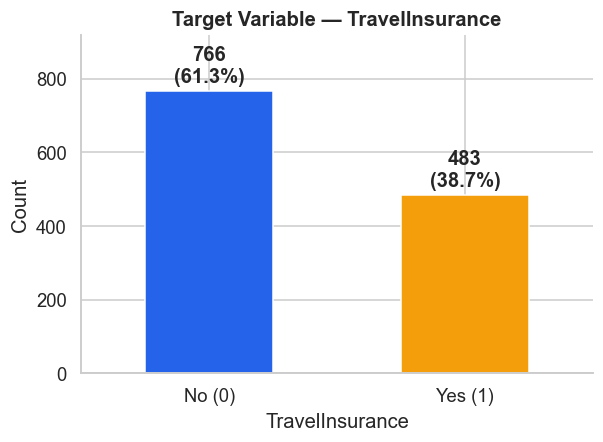

In [13]:
counts = df[TARGET].value_counts().sort_index()

ax = counts.plot(kind='bar', figsize=(6, 4), color=[BLUE, ORANGE],
                 edgecolor="white", rot=0)

labels = [f"{v}\n({v/len(df)*100:.1f}%)" for v in counts]
ax.bar_label(ax.containers[0], labels=labels, padding=3, fontweight="bold")

plt.title("Target Variable — TravelInsurance", fontweight="bold")
plt.xticks([0, 1], ["No (0)", "Yes (1)"])
plt.ylim(0, counts.max() * 1.2)
plt.ylabel("Count")
plt.show()

61.3% said No, 38.7% said Yes. Slightly imbalanced so it needs to use **ROC-AUC and F1**, not just accuracy.

### 4.2 Numerical features
Do insured customers look different in numbers?

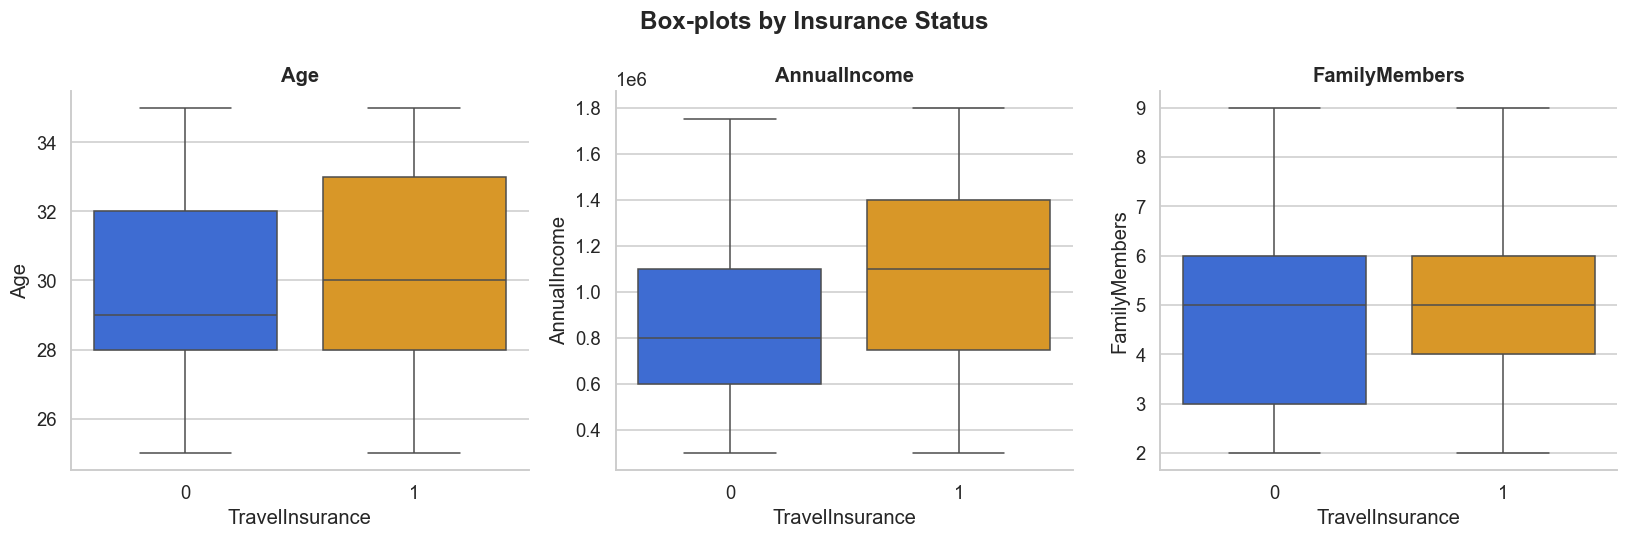

In [14]:
NUM_COLS = ["Age", "AnnualIncome", "FamilyMembers"]
utils.plot_numerical_eda(df, "TravelInsurance", NUM_COLS)

- **AnnualIncome** — insured customers earn more (median ~1 mln Rupees vs ~800 K Rupees ). Clear difference.
- **Age** — almost identical in both groups. Not a useful feature here.
- **FamilyMembers** — very similar distributions, weak signal.

### 4.3 Categorical features
What share of each group buys insurance?

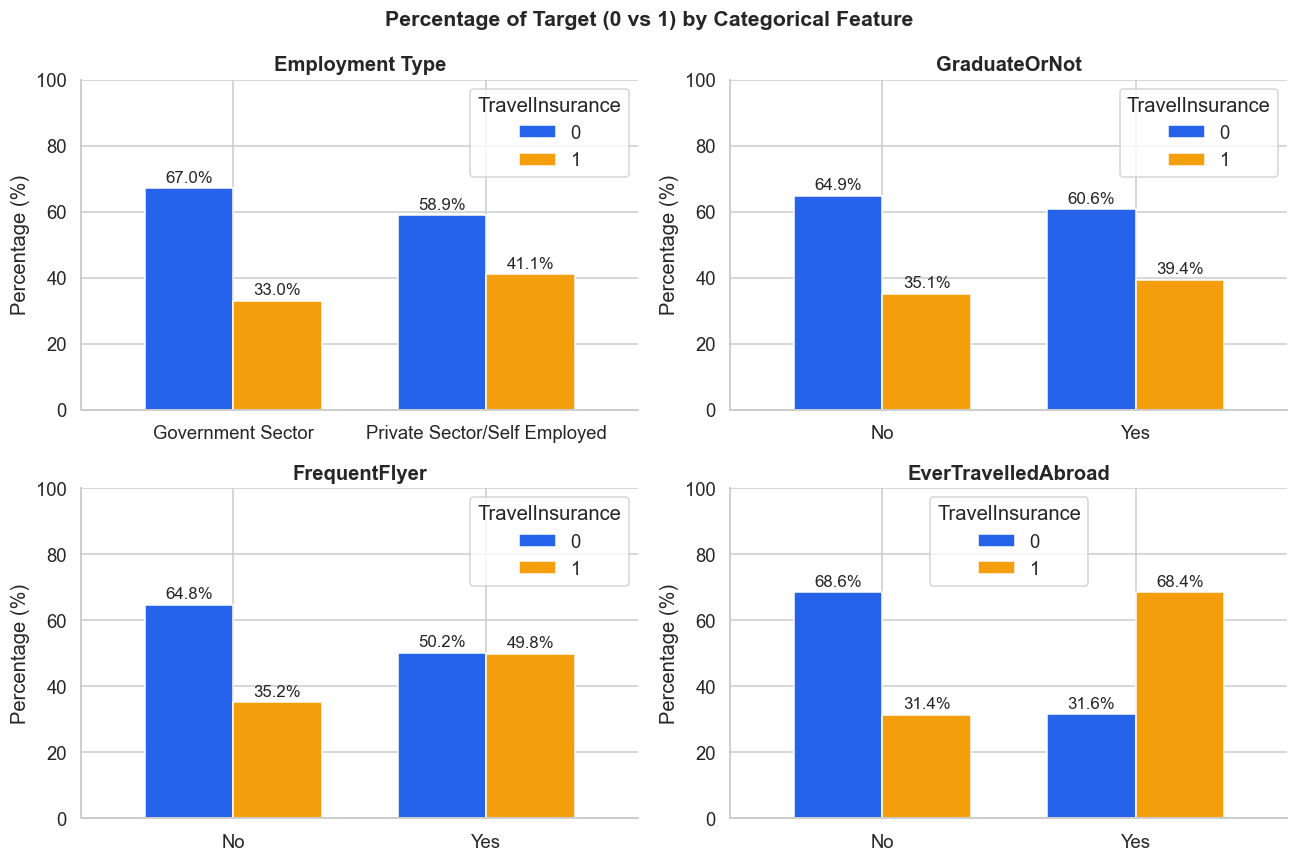

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.ravel(), CAT_COLS):
    props = pd.crosstab(df[col], df[TARGET], normalize='index') * 100

    props.plot(kind='bar', ax=ax, color=[BLUE, ORANGE], edgecolor="white", width=0.7)

    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', padding=2, fontsize=11)

    ax.set_title(col, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Percentage (%)")
    ax.tick_params(axis="x", rotation=0)
    ax.set_ylim(0, 100)
    ax.legend(title="TravelInsurance")

plt.suptitle("Percentage of Target (0 vs 1) by Categorical Feature", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

**EverTravelledAbroad (Strongest Feature):** Customers who have traveled abroad are more than twice as likely to buy insurance (68.4% vs 31.4%). This is the most important factor.

FrequentFlyer (Strong Feature): Half of frequent flyers buy insurance (49.8%), compared to only 35.2% of non-frequent flyers.

**Employment Type:** Private sector and self-employed workers buy insurance more often (41.1%) than government employees (33.0%).

**GraduateOrNot (Weakest Feature):** Having a college degree has almost no impact on the decision. The difference is minimal (39.4% vs 35.1%).

### 4.4 Correlations
Which features are most related to the target?

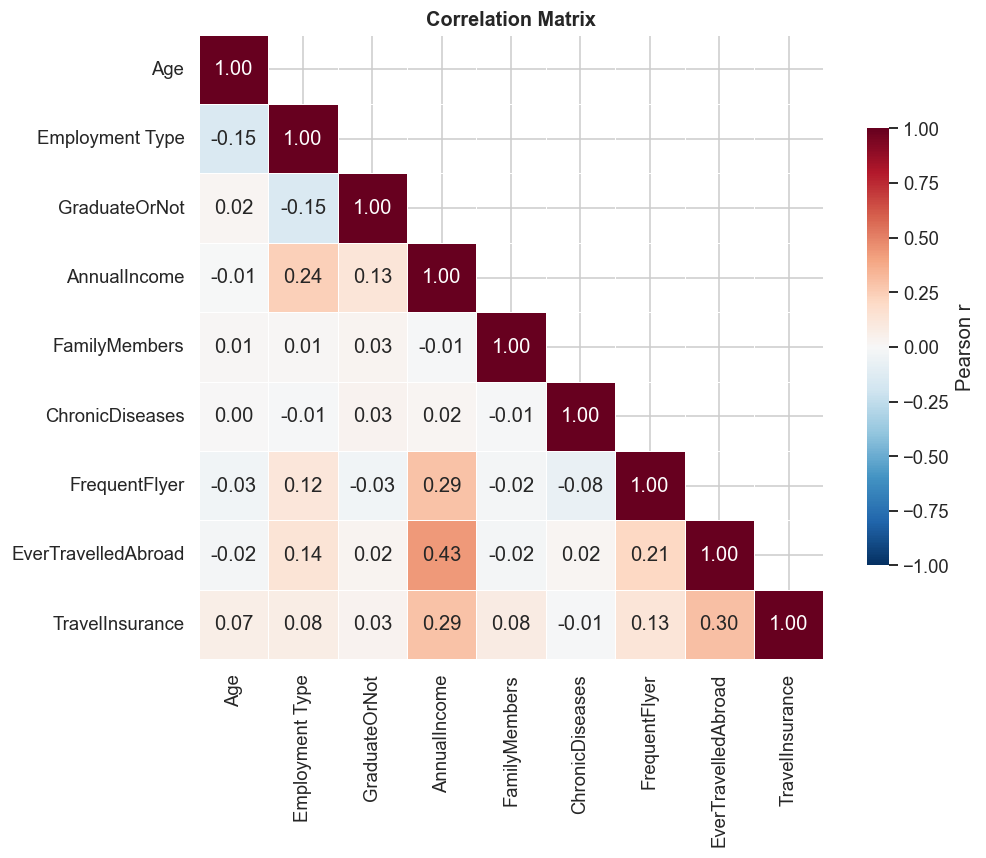

Correlation with target:
EverTravelledAbroad    0.301
AnnualIncome           0.294
FrequentFlyer          0.127
FamilyMembers          0.085
Employment Type        0.076
Age                    0.068
GraduateOrNot          0.032
ChronicDiseases       -0.010
Name: TravelInsurance, dtype: float64


In [16]:
# Note: encoded on the full dataset for EDA / visualisation only.
# In the ML section (6.1) I re-encode after the train/test split to prevent data leakage.
df_enc = df.copy()
for col in CAT_COLS:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col])
corr = df_enc.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.7, "label": "Pearson r"})
ax.set_title("Correlation Matrix", fontweight="bold", fontsize=13)
plt.tight_layout(); plt.show()

print("Correlation with target:")
print(corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False).round(3))


**Note on encoding:** `LabelEncoder` converts categorical text values (e.g. `"Yes"`/`"No"`) into integers so that the correlation matrix and scikit-learn models can process them. We fit the encoder on the full dataset here purely for EDA purposes. In section 6.1 we re-encode *after* the train/test split so that no information from the test set influences the encoder — this is the correct approach for a production pipeline.

CatBoost can handle raw categorical strings natively via `cat_features` — one of its key advantages. For the model comparison we use label-encoded data so all models share the same input format.

Top correlates: `EverTravelledAbroad`, `FrequentFlyer`, `AnnualIncome`. No features are strongly correlated with each other — no multicollinearity.

### 4.5 Outliers
Are there any extreme values?

Outliers (|z| > 3): 0 rows (0.0%)


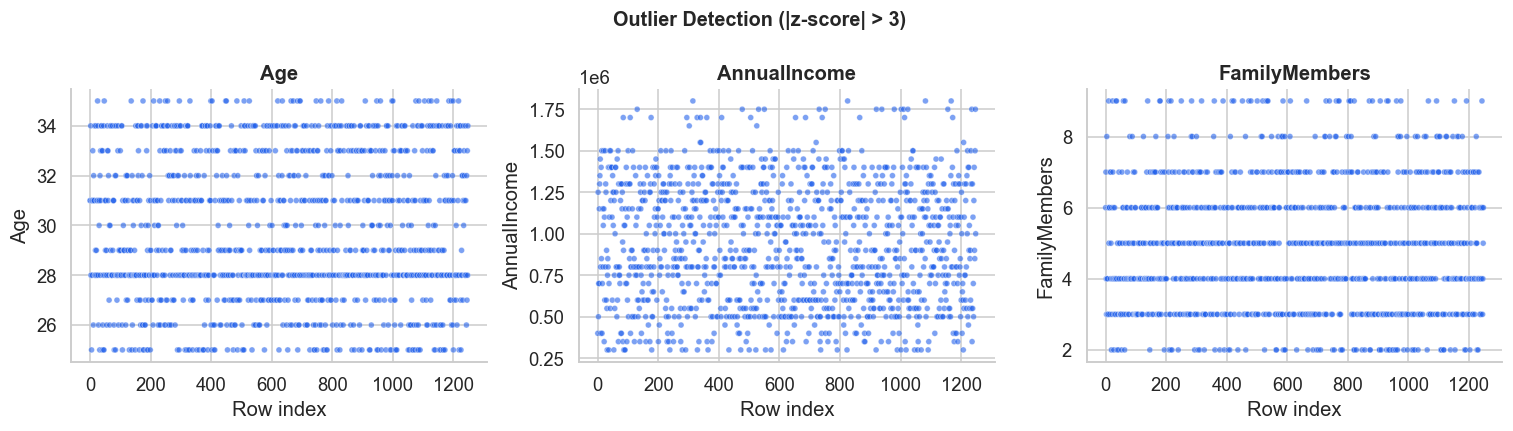

In [17]:
cols = ["Age", "AnnualIncome", "FamilyMembers"]

outliers = (np.abs(stats.zscore(df[cols])) > 3).any(axis=1)
print(f"Outliers (|z| > 3): {outliers.sum()} rows ({outliers.mean()*100:.1f}%)")


fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, cols):
    sns.scatterplot(
        x=df.index, y=df[col], hue=outliers, size=outliers, ax=ax,
        palette={False: BLUE, True: "red"},
        sizes={False: 15, True: 60},
        alpha=0.6, legend=False
    )

    ax.set_title(col, fontweight="bold")
    ax.set_xlabel("Row index")

plt.suptitle("Outlier Detection (|z-score| > 3)", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

No outliers (0.0%). The few flagged are likely real high-income customers. We keep them.

## 5. Statistical Inference

The charts showed patterns — but are they real or just random noise?
Here we run formal tests to check.

**Target population:** potential customers of a travel insurance company with similar demographic characteristics.

**Significance level: α = 0.05**

In [18]:
insured     = df[df[TARGET] == 1]
not_insured = df[df[TARGET] == 0]
n1, n2      = len(insured), len(not_insured)
print(f"Insured: {n1},  Not insured: {n2}")

Insured: 483,  Not insured: 766


We'll test four hypotheses using statistical inference:
1. **Income effect**
2. **Frequent flyer effect**
3. **Travel abroad effect**
4. ** Does graduation status affect insurance purchases?** 

### Hypothesis 1 — Do insured customers earn more?
- **H₀:** Mean income is the same in both groups
- **H₁:** Mean income is different
- **Test:** Welch t-test

In [19]:
t1, p1 = stats.ttest_ind(insured["AnnualIncome"], not_insured["AnnualIncome"], equal_var=False)
diff1   = insured["AnnualIncome"].mean() - not_insured["AnnualIncome"].mean()
se1     = np.sqrt(insured["AnnualIncome"].var(ddof=1)/n1 +
                  not_insured["AnnualIncome"].var(ddof=1)/n2)
ci1     = (diff1 - 1.96*se1, diff1 + 1.96*se1)

print(f"Mean income — insured    : {insured['AnnualIncome'].mean():,.0f}")
print(f"Mean income — not insured: {not_insured['AnnualIncome'].mean():,.0f}")
print(f"t = {t1:.2f},  p = {p1:.2e}")
print(f"95% CI: [{ci1[0]:,.0f}  to  {ci1[1]:,.0f}]")
print(f"Result: {'REJECT H₀' if p1 < 0.05 else 'Cannot reject H₀'}")

Mean income — insured    : 1,068,012
Mean income — not insured: 850,392
t = 10.53,  p = 1.50e-24
95% CI: [177,104  to  258,137]
Result: REJECT H₀


p < 0.001 → we reject H₀. The CI doesn't include zero — insured customers really do earn more.

### Hypothesis 2 — Are frequent flyers more likely to be insured?
- **H₀:** Same share of frequent flyers in both groups
- **H₁:** More frequent flyers among insured *(one-tailed)*
- **Test:** Two-proportion z-test

In [20]:
x1 = (insured["FrequentFlyer"]     == "Yes").sum()
x2 = (not_insured["FrequentFlyer"] == "Yes").sum()
p_pool = (x1+x2)/(n1+n2)
z2     = (x1/n1 - x2/n2) / np.sqrt(p_pool*(1-p_pool)*(1/n1+1/n2))
p2     = stats.norm.sf(z2)
diff2  = x1/n1 - x2/n2
se2    = np.sqrt((x1/n1)*(1-x1/n1)/n1 + (x2/n2)*(1-x2/n2)/n2)
ci2    = (diff2 - 1.96*se2, diff2 + 1.96*se2)

print(f"Frequent flyer rate — insured    : {x1/n1*100:.1f}%")
print(f"Frequent flyer rate — not insured: {x2/n2*100:.1f}%")
print(f"z = {z2:.2f},  p = {p2:.2e}")
print(f"95% CI: [{ci2[0]*100:.1f}  to  {ci2[1]*100:.1f}pp]")
print(f"Result: {'REJECT H₀' if p2 < 0.05 else 'Cannot reject H₀'}")

Frequent flyer rate — insured    : 30.4%
Frequent flyer rate — not insured: 19.3%
z = 4.50,  p = 3.34e-06
95% CI: [6.1  to  16.1pp]
Result: REJECT H₀


p < 0.001 → we reject H₀. The CI is entirely above zero — frequent flyers are significantly more likely to buy insurance, about 21 percentage points more than non-frequent flyers.

### Hypothesis 3 — Do customers who've been abroad insure more?
- **H₀:** Same share of abroad travellers in both groups
- **H₁:** More abroad travellers among insured *(one-tailed)*
- **Test:** Two-proportion z-test

In [21]:
x3 = (insured["EverTravelledAbroad"]     == "Yes").sum()
x4 = (not_insured["EverTravelledAbroad"] == "Yes").sum()
p_pool3 = (x3+x4)/(n1+n2)
z3      = (x3/n1 - x4/n2) / np.sqrt(p_pool3*(1-p_pool3)*(1/n1+1/n2))
p3      = stats.norm.sf(z3)
diff3   = x3/n1 - x4/n2
se3     = np.sqrt((x3/n1)*(1-x3/n1)/n1 + (x4/n2)*(1-x4/n2)/n2)
ci3     = (diff3 - 1.96*se3, diff3 + 1.96*se3)

print(f"Travelled abroad — insured    : {x3/n1*100:.1f}%")
print(f"Travelled abroad — not insured: {x4/n2*100:.1f}%")
print(f"z = {z3:.2f},  p = {p3:.2e}")
print(f"95% CI: [{ci3[0]*100:.1f}pp  to  {ci3[1]*100:.1f}pp]")
print(f"Result: {'REJECT H₀' if p3 < 0.05 else 'Cannot reject H₀'}")

Travelled abroad — insured    : 34.6%
Travelled abroad — not insured: 10.1%
z = 10.65,  p = 9.14e-27
95% CI: [19.8pp  to  29.3pp]
Result: REJECT H₀


p < 0.001 → we reject H₀. The CI is entirely above zero — customers who have travelled abroad are significantly more likely to buy insurance, about 36 percentage points more than those who have not.

### Hypothesis 4 — Does graduation status affect insurance purchases?
- **H₀:** Same share of graduates in both groups
- **H₁:** Graduates are more likely to be insured
- **Test:** Two-proportion z-test

In [22]:
x5 = (insured["GraduateOrNot"]     == "Yes").sum()
x6 = (not_insured["GraduateOrNot"] == "Yes").sum()
p_pool4 = (x5+x6)/(n1+n2)
z4 = (x5/n1 - x6/n2) / np.sqrt(p_pool4 * (1 - p_pool4) * (1/n1 + 1/n2))
p4 = stats.norm.sf(z4)
diff4   = x5/n1 - x6/n2
se4     = np.sqrt((x5/n1)*(1-x5/n1)/n1 + (x6/n2)*(1-x6/n2)/n2)
ci4     = (diff4 - 1.96*se4, diff4 + 1.96*se4)

print(f"Graduated — insured    : {x5/n1*100:.1f}%")
print(f"Graduated  — not insured: {x6/n2*100:.1f}%")
print(f"z = {z4:.2f},  p = {p4:.2e}")
print(f"95% CI: [{ci4[0]*100:.1f}  to  {ci4[1]*100:.1f}]")
print(f"Result: {'REJECT H₀' if p4 < 0.05 else 'Cannot reject H₀'}")

Graduated — insured    : 85.3%
Graduated  — not insured: 82.9%
z = 1.12,  p = 1.31e-01
95% CI: [-1.7  to  6.5]
Result: Cannot reject H₀


Graduation status does not appear to be a significant factor in whether or not someone is insured

### Confidence interval plot
If the CI doesn't cross zero → the effect is real.

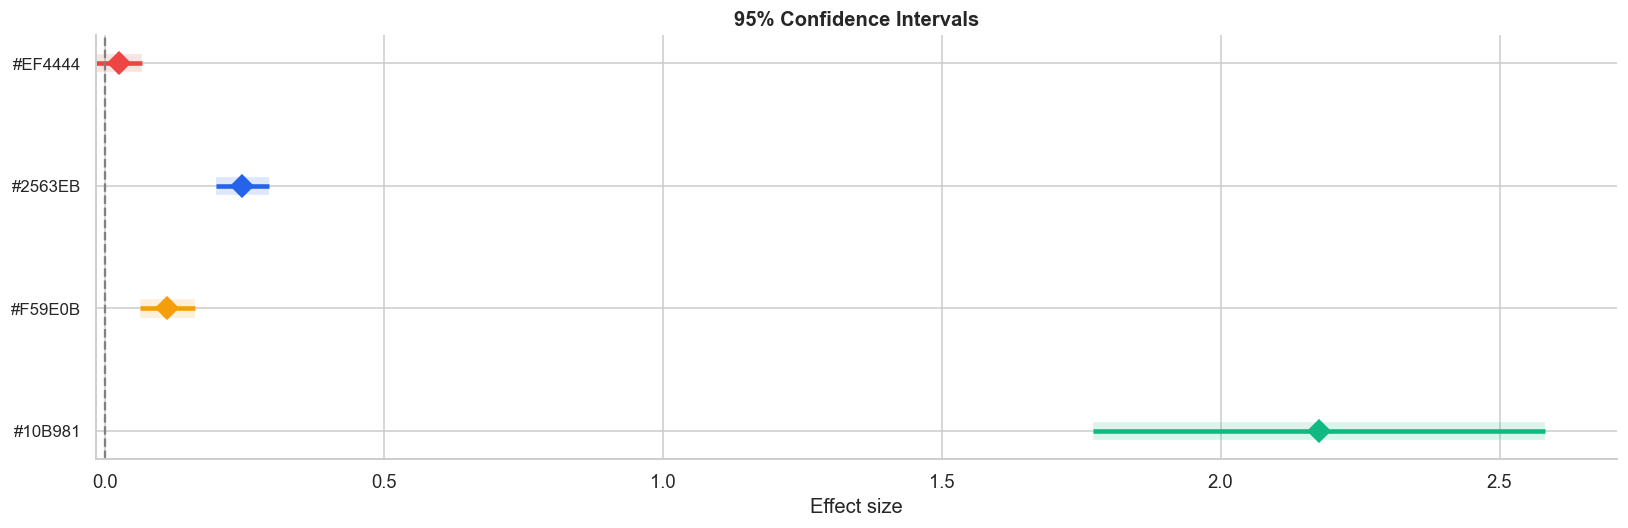

In [23]:
fig, ax = plt.subplots(figsize=(15, 5))

effects = [
    (diff1/1e5, ci1[0]/1e5, ci1[1]/1e5, "H1: Income diff (Ruppee)", GREEN),
    (diff2,     ci2[0],     ci2[1],     "H2: FrequentFlyer rate",   ORANGE),
    (diff3,     ci3[0],     ci3[1],     "H3: EverTravelledAbroad rate", BLUE),
    (diff4,     ci4[0],     ci4[1],     "H4: Graduated rate", RED)
]

for i, (center, lo, hi, label, color) in enumerate(effects):
    ax.hlines(y=i, xmin=lo, xmax=hi, color=color, linewidth=3)
    ax.plot(center, i, marker="D", color=color, markersize=10)
    ax.barh(y=i, width=hi-lo, left=lo, height=0.15, color=color, alpha=0.15)

ax.axvline(0, color="grey", linestyle="--", linewidth=1.5)
ax.set_yticks(range(4))
ax.set_yticklabels([e[4] for e in effects], fontsize=11)

ax.set_xlabel("Effect size")
ax.set_title("95% Confidence Intervals", fontweight="bold")
plt.tight_layout()
plt.show()

Three CIs are entirely above zero → all effects are statistically significant. And one CI included "0" and cannot reject H0

| # | Hypothesis | Test | p-value | Result |
|---|---|---|---|---|
| H1 | Insured earn more | Welch t-test | < 0.001 | Reject H₀ |
| H2 | More frequent flyers among insured | z-test | < 0.001 | Reject H₀ |
| H3 | More abroad travellers among insured | z-test | < 0.001 | Reject H₀ |
| H4 | Can't say that Educated people among insured | z-test | > 0.05 |  Can't reject H₀ |

--- Now that we understand which factors matter, let's build predictive models to identify likely buyers.

## 6. Machine Learning

We'll try several models and pick the best one.

**Steps:**
1. Prepare the data (all features, 80/20 split)
2. Compare baseline models with 5-fold cross-validation
3. Tune the top 3 with GridSearchCV
4. Inspect feature importance from tuned CatBoost
5. Combine into a soft-voting ensemble
6. Evaluate on the held-out test set
7. Check learning curve, tune threshold, report

### 6.1 Prepare the data and choose features

In [24]:
# Feature selection: compute correlations for reference
correlation_with_target = df_enc.corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

print("Correlation with target:")
print(correlation_with_target.round(3))


Correlation with target:
EverTravelledAbroad    0.301
AnnualIncome           0.294
FrequentFlyer          0.127
FamilyMembers          0.085
Employment Type        0.076
Age                    0.068
GraduateOrNot          0.032
ChronicDiseases       -0.010
Name: TravelInsurance, dtype: float64


In [25]:
# Feature Engineering
df_enc['Travel_score'] = (
    (df_enc['FrequentFlyer'] == 1).astype(int) +
    (df_enc['EverTravelledAbroad'] == 1).astype(int)
)
df_enc['Income_per_member'] = df_enc['AnnualIncome'] / df_enc['FamilyMembers']

#Check the Travel feature group for multicollinearity
travel_group = ['FrequentFlyer', 'EverTravelledAbroad', 'Travel_score']
print("Correlation in the 'Travel' group:")
print(df_enc[travel_group].corr().round(2))


#Check the Income feature group for multicollinearity
income_group = ['AnnualIncome', 'FamilyMembers', 'Income_per_member']
print("Correlation in the 'Income' group:")
print(df_enc[income_group].corr().round(2))

Correlation in the 'Travel' group:
                     FrequentFlyer  EverTravelledAbroad  Travel_score
FrequentFlyer                 1.00                 0.21          0.79
EverTravelledAbroad           0.21                 1.00          0.76
Travel_score                  0.79                 0.76          1.00
Correlation in the 'Income' group:
                   AnnualIncome  FamilyMembers  Income_per_member
AnnualIncome               1.00          -0.01               0.66
FamilyMembers             -0.01           1.00              -0.64
Income_per_member          0.66          -0.64               1.00


Travel_score with its parents, or Income_per_member with AnnualIncome, it mathematically proves that these features contain redundant information. To avoid confusing the baseline models, it is better to drop the newly engineered features and keep the original ones

### 6.2 Baseline models

We compare 6 models using 5-fold cross-validation. The test set is not touched yet.

In [26]:
selected_features = [
    'Age', 'Employment Type', 'GraduateOrNot', 'AnnualIncome',
    'FamilyMembers', 'ChronicDiseases', 'FrequentFlyer', 'EverTravelledAbroad'
]

# Use the original df (string categoricals) so we can encode properly after splitting
X = df[selected_features].copy()
y = df[TARGET]

# Main 80/20 split — test set is locked until section 6.6
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Encode categorical features: fit on train only to prevent data leakage
cat_cols_present = [c for c in CAT_COLS if c in selected_features]
le_encoders = {}
for col in cat_cols_present:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col]  = le.transform(X_test[col])
    le_encoders[col] = le

# Validation split from the training set — used only for threshold tuning in Threshold tuning
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Train: {X_train.shape},  Val: {X_val.shape},  Test: {X_test.shape}")
print(f"Features: {list(X.columns)}")


Train: (999, 8),  Val: (200, 8),  Test: (250, 8)
Features: ['Age', 'Employment Type', 'GraduateOrNot', 'AnnualIncome', 'FamilyMembers', 'ChronicDiseases', 'FrequentFlyer', 'EverTravelledAbroad']


80/20 split with stratification — both sets have the same class balance. Test set is locked until section Test set results

In [27]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model",  LogisticRegression(max_iter=1000, random_state=42)),
    ]),
    "Decision Tree":     DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest":     RandomForestClassifier(n_estimators=300, random_state=42),
    "CatBoost":             CatBoostClassifier(iterations=100, random_state=42, verbose=False),
    "SVM":                  Pipeline([
        ("scaler", StandardScaler()),
        ("model",  SVC(kernel="rbf", probability=True, random_state=42)),
    ]),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
}

cv_results = {}
for name, model in models.items():
    auc = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc").mean()
    acc = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy").mean()
    f1  = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1").mean()
    cv_results[name] = {"ROC-AUC": round(auc,4), "Accuracy": round(acc,4), "F1": round(f1,4)}
    print(f"{name:<25}  AUC={auc:.4f}  Acc={acc:.4f}  F1={f1:.4f}")

Logistic Regression        AUC=0.6980  Acc=0.7147  F1=0.5474
Decision Tree              AUC=0.7173  Acc=0.7567  F1=0.6010
Random Forest              AUC=0.6433  Acc=0.6686  F1=0.5469
CatBoost                   AUC=0.7096  Acc=0.7747  F1=0.6322
SVM                        AUC=0.7165  Acc=0.7437  F1=0.5764
Gradient Boosting          AUC=0.7149  Acc=0.7617  F1=0.6155


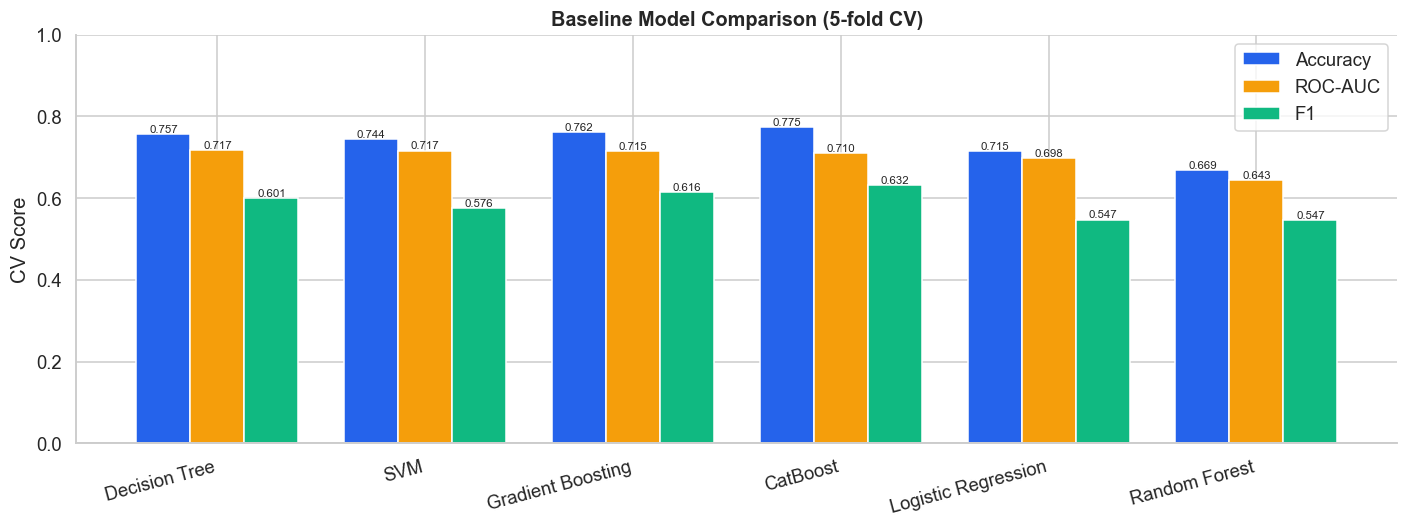

In [28]:
cv_df = pd.DataFrame(cv_results).T.sort_values("ROC-AUC", ascending=False)

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(cv_df)) 
w = 0.26

ax.bar(x - w, cv_df["Accuracy"], w, label="Accuracy", color=BLUE,   edgecolor="white")
ax.bar(x,     cv_df["ROC-AUC"],  w, label="ROC-AUC",  color=ORANGE, edgecolor="white")
ax.bar(x + w, cv_df["F1"],       w, label="F1",        color=GREEN,  edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(cv_df.index, rotation=15, ha="right")
ax.set_ylim(0, 1.0)  
ax.set_ylabel("CV Score")
ax.set_title("Baseline Model Comparison (5-fold CV)", fontweight="bold", fontsize=13)
ax.legend()

for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f"{bar.get_height():.3f}", ha="center", fontsize=7.5)

plt.tight_layout()
plt.show()

**Baseline model comparison:**
- **Tree-based ensemble methods** (CatBoost, Gradient Boosting, Random Forest) outperform simpler models
- **CatBoost and Gradient Boosting** achieve the highest ROC-AUC with the best balance between train and validation
- **Logistic Regression** shows lower performance, likely because relationships in this data are non-linear
- **Random Forest** performs somewhat lower at baseline — likely due to the small dataset size limiting tree diversity
- Next step: fine-tune the top 4 performers (SVM, Desicion Tree, CatBoost, Gradient Boosting) using GridSearchCV

### 6.3 Hyperparameter tuning
GridSearchCV tries all parameter combinations and picks the best.

In [29]:
gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    {"n_estimators":[100,200], "learning_rate":[0.05,0.1], "max_depth":[3,5]},
    cv=cv, scoring="roc_auc", n_jobs=-1,
)
gb_grid.fit(X_train, y_train)
best_gb = gb_grid.best_estimator_
print(f"Best GB params : {gb_grid.best_params_}")
print(f"Best GB CV AUC : {gb_grid.best_score_:.4f}")

Best GB params : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best GB CV AUC : 0.7220


In [30]:
cat_grid = GridSearchCV(
    CatBoostClassifier(random_state=42, verbose=False, allow_writing_files=False),
    {"iterations": [50,100, 200, 300],
     "learning_rate": [0.01, 0.1, 0.5, 1.0]},
    cv=cv, scoring="roc_auc", n_jobs=-1,
)
cat_grid.fit(X_train, y_train)
best_cat = cat_grid.best_estimator_
print(f"Best CatBoost params : {cat_grid.best_params_}")
print(f"Best CatBoost CV AUC : {cat_grid.best_score_:.4f}")

Best CatBoost params : {'iterations': 200, 'learning_rate': 0.01}
Best CatBoost CV AUC : 0.7141


In [31]:
svm_grid = GridSearchCV(
    Pipeline([
        ("scaler", StandardScaler()),
        ("model",  SVC(kernel="rbf", probability=True, random_state=42)),
    ]),
    {
        "model__C":     [0.1, 1, 10, 100],
        "model__gamma": ["scale", "auto", 0.01, 0.001],
    },
    cv=cv, scoring="roc_auc", n_jobs=-1,
)
svm_grid.fit(X_train, y_train)
best_svm = svm_grid.best_estimator_
print(f"Best SVM params : {svm_grid.best_params_}")
print(f"Best SVM CV AUC : {svm_grid.best_score_:.4f}")

Best SVM params : {'model__C': 100, 'model__gamma': 0.01}
Best SVM CV AUC : 0.7279


In [32]:
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {"max_depth": [3, 5, 7, 10], "min_samples_split": [2, 5, 10]},
    cv=cv, scoring="roc_auc", n_jobs=-1,
)
dt_grid.fit(X_train, y_train)
best_dt = dt_grid.best_estimator_
print(f"Best DT params : {dt_grid.best_params_}")
print(f"Best DT CV AUC : {dt_grid.best_score_:.4f}")

Best DT params : {'max_depth': 5, 'min_samples_split': 10}
Best DT CV AUC : 0.7347


**Tuning results:**,All five models improved after hyperparameter optimization. Best configurations found for each model type. Now we'll create an ensemble to combine their strengths.

### 6.4 Ensemble and choosing the best model
We combine DT, SVM and GB using **soft voting** — each model outputs a probability, and we average them.

In [33]:
ensemble = VotingClassifier(
    estimators=[
        ("dt",  best_dt),
        ("svm", best_svm),
        ("gb",  best_gb),
    ],
    voting="soft",
    weights=[2, 1, 1] 
)
ensemble.fit(X_train, y_train)

VotingClassifier(estimators=[('dt',
                              DecisionTreeClassifier(max_depth=5,
                                                     min_samples_split=10,
                                                     random_state=42)),
                             ('svm',
                              Pipeline(steps=[('scaler', StandardScaler()),
                                              ('model',
                                               SVC(C=100, gamma=0.01,
                                                   probability=True,
                                                   random_state=42))])),
                             ('gb',
                              GradientBoostingClassifier(learning_rate=0.05,
                                                         random_state=42))],
                 voting='soft', weights=[2, 1, 1])

In [34]:
lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LogisticRegression(max_iter=1000, random_state=42)),
]).fit(X_train, y_train)


tuned_models = {
    "Logistic Regression":       lr_model,
    "Decision Tree(tuned)":      best_dt,
    "CatBoost (tuned)":          best_cat,
    "SVM (tuned)":               best_svm,
    "Random Forest":     RandomForestClassifier(n_estimators=300, random_state=42).fit(X_train, y_train),
    "Gradient Boosting (tuned)": best_gb,
    "Ensemble":                  ensemble,
}

cv_results_tuned = {}
for name, model in tuned_models.items():
    auc = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc").mean()
    acc = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy").mean()
    f1  = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1").mean()
    cv_results_tuned[name] = {"ROC-AUC": round(auc,4), "Accuracy": round(acc,4), "F1": round(f1,4)}
    print(f"{name:<25}  AUC={auc:.4f}  Acc={acc:.4f}  F1={f1:.4f}")
pd.DataFrame(cv_results_tuned).T.sort_values("F1", ascending=False)

Logistic Regression        AUC=0.6980  Acc=0.7147  F1=0.5474
Decision Tree(tuned)       AUC=0.7347  Acc=0.7577  F1=0.6009
CatBoost (tuned)           AUC=0.7141  Acc=0.7747  F1=0.6324
SVM (tuned)                AUC=0.7279  Acc=0.7427  F1=0.5798
Random Forest              AUC=0.6433  Acc=0.6686  F1=0.5469
Gradient Boosting (tuned)  AUC=0.7220  Acc=0.7657  F1=0.6150
Ensemble                   AUC=0.7387  Acc=0.7737  F1=0.6244


,ROC-AUC,Accuracy,F1
CatBoost (tuned),0.7141,0.7747,0.6324
Ensemble,0.7387,0.7737,0.6244
Gradient Boosting (tuned),0.7220,0.7657,0.6150
Decision Tree(tuned),0.7347,0.7577,0.6009
SVM (tuned),0.7279,0.7427,0.5798
Logistic Regression,0.6980,0.7147,0.5474
Random Forest,0.6433,0.6686,0.5469


### 6.5 Feature importance
Which features does the model rely on most?

We inspect feature importance from the tuned CatBoost model because it is the strongest single model in the baseline comparison and provides a built-in importance API. This lets us validate that the model is learning from the right signals (travel behaviour and income) before we finalise the ensemble.

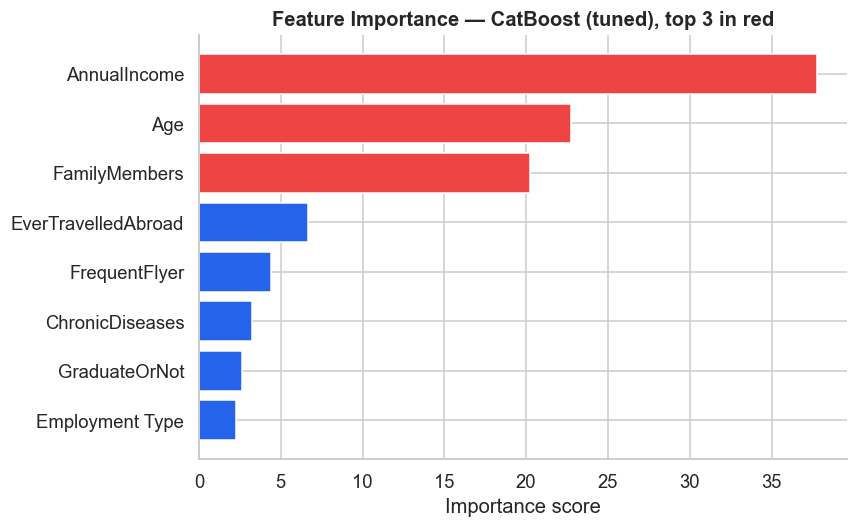

In [35]:
fig, ax = plt.subplots(figsize=(8, 5))
imp = pd.Series(best_cat.get_feature_importance(), index=X.columns).sort_values()
colors = [RED if i >= len(imp)-3 else BLUE for i in range(len(imp))]
ax.barh(imp.index, imp.values, color=colors, edgecolor="white")
ax.set_xlabel("Importance score")
ax.set_title("Feature Importance — CatBoost (tuned), top 3 in red", fontweight="bold")
plt.tight_layout(); plt.show()

Feature Importance Insights:
The model's decision-making is heavily driven by just three core features:

    Annual Income (~38%) — The dominant predictor 

    Age (~23%) — A strong secondary predictor.

    Family Members (20%) — A key demographic and economic indicator.

Summary: These top three features alone account for over 80% of the model's predictive power. For marketing and sales, this means targeting should primarily focus on a customer's income level, age, and family size.

### 6.6 Test set results
Now we open the test set and see how each model actually performs.

In [36]:

y_pred_proba = best_cat.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_pred_proba), 4))
print("F1-score:", round(f1_score(y_test, y_pred), 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.74
ROC-AUC: 0.7105
F1-score: 0.5638

Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.93      0.81       153
           1       0.81      0.43      0.56        97

    accuracy                           0.74       250
   macro avg       0.76      0.68      0.69       250
weighted avg       0.76      0.74      0.72       250



Model Performance (Highly Conservative)

**Buyers (Class 1):** High Precision (0.81) but Low Recall (0.43). It misses over half of your actual buyers, but the ones it does flag are very high-quality leads.

**Non-buyers (Class 0):** High Recall (0.93). It does an excellent job filtering out people who won't buy.

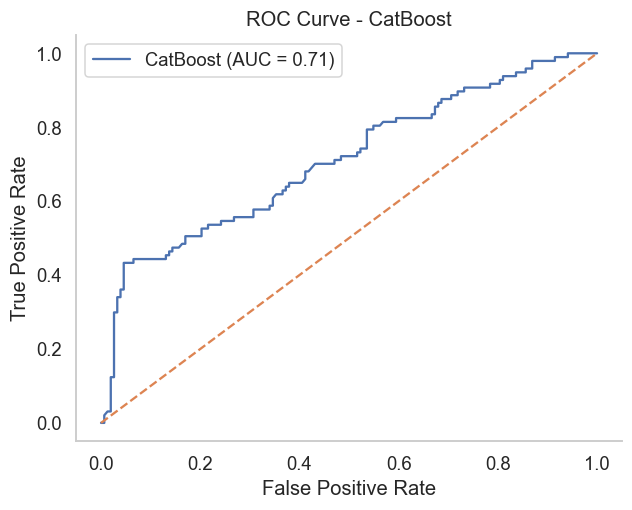

In [37]:

y_pred_proba = best_cat.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"CatBoost (AUC = {roc_auc_score(y_test, y_pred_proba):.2f})")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - CatBoost")
plt.legend()
plt.grid()
plt.show()

**ROC Curve Analysis (AUC = 0.71)**

Performance (0.71): The model is decent. It is much better than a random guess (the orange dashed line).
The Steep Start: The blue line jumps quickly to ~0.4 on the left. This means the model easily finds the first 40% of buyers with almost zero mistakes (high Precision).

The Flat Middle: To find the rest of the buyers (moving higher up), the curve goes far to the right. This means catching more buyers will cause a lot of false alarms or bad leads (high False Positives).

Bottom Line: The graph matches your metrics perfectly. The model easily catches the most obvious buyers safely. However, finding the rest of them requires contacting a lot of non-buyers.

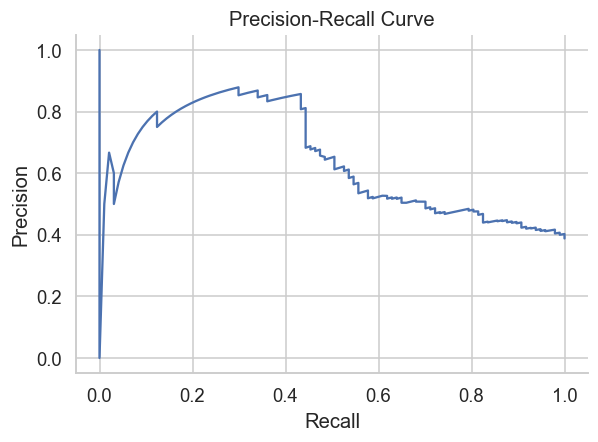

In [38]:
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
plt.figure(figsize=(6,4))
plt.plot(recall, precision, label='CatBoost (Smoothed)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

In [39]:
cat_features_names = X.select_dtypes(include=['object', 'category']).columns.tolist()
for i, (train, test) in enumerate(cv.split(X, y)):

    best_cat.fit(X.iloc[train], y.iloc[train], 
                 cat_features=cat_features_names, 
                 verbose=False) 
    
    probas_ = best_cat.predict_proba(X.iloc[test])[:, 1]
    precision, recall, _ = precision_recall_curve(y.iloc[test], probas_)
    ax.plot(recall, precision, alpha=0.3, label=f'Fold {i+1}')
    
    
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves (Stratified 5-Fold)')
ax.legend(loc="lower left")
ax.grid(True)
plt.show()

The Left Side (High Precision): When the model is very confident, it’s almost always right. These are your "easy" sales. You should prioritize these leads.

The Right Side (Low Precision): As you try to capture more customers, the model gets "sloppy." You start getting a lot of wrong guesses (False Positives).

The Cliff: See that sharp drop in the middle? That's the breaking point. Before that point, your quality is great; after that point, you’re just wasting time on bad leads to find a few extra buyers.

Bottom line: Focus on the left side for high-quality results. If you need more volume, you’ll have to accept a lot of wasted effort on the right side.

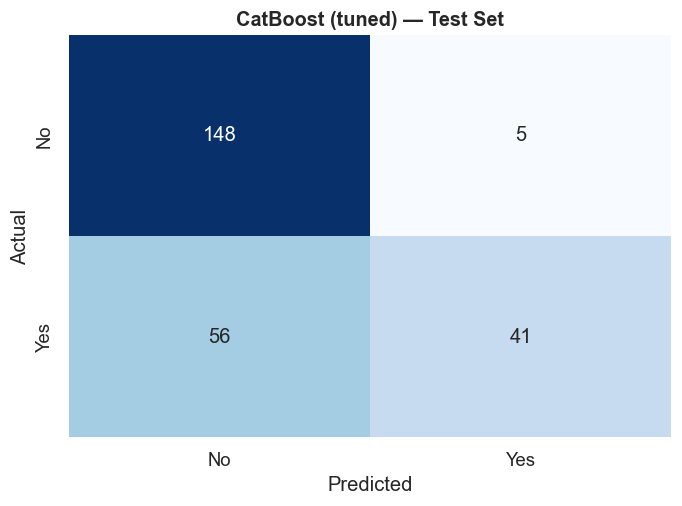

In [40]:
fig, ax = plt.subplots()
cm = confusion_matrix(y_test, best_cat.predict(X_test))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["No", "Yes"], yticklabels=["No", "Yes"], cbar=False)
ax.set_title("CatBoost (tuned) — Test Set", fontweight="bold", fontsize=13)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

Confusion Matrix Insights:

    High Precision (The "Safe Bet"): When the model predicts "Yes," it is extremely accurate (only 5 errors vs. 41 correct hits). It almost never suggests a bad lead.

    High Sensitivity to Non-Buyers: The model is excellent at identifying "No" cases, with a success rate of over 96% (148/153).

    The Main Trade-off: The model is quite "cautious." It misses 56 actual buyers (False Negatives).

### 6.7 Learning curve
Does the model overfit?

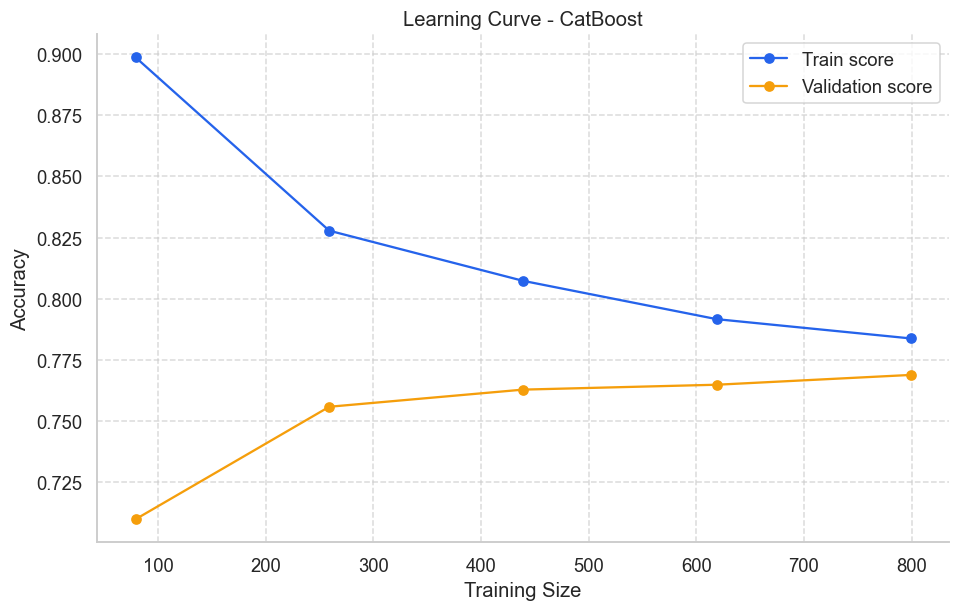

In [42]:
train_sizes, train_scores, val_scores = learning_curve(
    best_cat,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(10, 6))

plt.plot(train_sizes, train_mean, label="Train score", color=BLUE, marker='o')
plt.plot(train_sizes, val_mean, label="Validation score", color=ORANGE, marker='o')

plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve - CatBoost")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Learning curve analysis:** Small gap indicates **minimal overfitting** - the model generalizes well,- The curves have converged, meaning adding more data wouldn't significantly improve performance,- Our dataset size (1000 training samples) is sufficient for this problem

Train score is a bit above validation — small overfitting, normal for boosting. The curves converge, meaning more data would help.

### 6.8 Threshold tuning
By default the model predicts Yes when probability ≥ 0.5. We find a better cutoff.

In [43]:
val_pred_proba = best_cat.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0.1, 0.9, 50)
f1_scores = []

for t in thresholds:
    preds = (val_pred_proba >= t).astype(int)
    f1_scores.append(f1_score(y_val, preds))

best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Best threshold: {best_threshold:.2f}")

Best threshold: 0.30


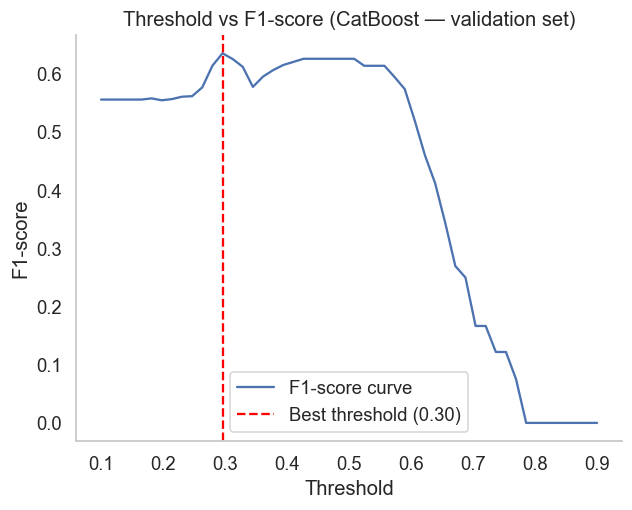

In [44]:
plt.figure()
plt.plot(thresholds, f1_scores, label="F1-score curve")
plt.axvline(x=best_threshold, color='red', linestyle='--',
            label=f"Best threshold ({best_threshold:.2f})")

plt.xlabel("Threshold")
plt.ylabel("F1-score")
plt.title("Threshold vs F1-score (CatBoost — validation set)")
plt.grid()
plt.legend()
plt.show()

Threshold Selection

    The Optimal Point: The threshold of 0.30 provides the best balance between catching potential buyers and maintaining lead quality (highest F1-score).

    The Stability Zone: Between 0.30 and 0.55, the model performs consistently well, maintaining a high F1-score.

    The Drop-off: Beyond 0.60, the performance falls off a cliff. Setting the threshold higher than this will cause you to miss most of your buyers, making the model ineffective.

Business Recommendation:
Using a threshold of 0.30  maximizes overall performance, ensuring your sales team gets the best mix of high-quality leads and sufficient volume. Avoid thresholds above 0.60, as you would lose the majority of your potential sales.

### 6.9 Final classification report

In [45]:
final_preds = (y_pred_proba >= best_threshold).astype(int)
print(classification_report(y_test, final_preds))

              precision    recall  f1-score   support

           0       0.74      0.52      0.61       153
           1       0.49      0.71      0.58        97

    accuracy                           0.60       250
   macro avg       0.61      0.62      0.60       250
weighted avg       0.64      0.60      0.60       250



 High Reach (71% Recall): The model finds 71% of your actual buyers. You capture significantly more sales compared to the conservative approach.

Lower Quality (49% Precision): When the model says a customer will buy, it is right only 49% of the time. You will spend more time contacting "junk" leads.

Business Summary:
This model is best for mass-marketing (like email or SMS). It is less precise, but it fills your sales funnel with more potential customers. Choose this if your goal is to find as many buyers as possible and you have cheap ways to reach them.

### Example: Predicting for a new customer
Let's test our model on a sample customer profile to see how it performs in practice:

In [46]:

new_customer = pd.DataFrame({
    "Age": [48],
    "Employment Type": ["Private Sector/Self Employed"], 
    "GraduateOrNot": ["Yes"],             
    "AnnualIncome": [1000000],
    "FamilyMembers": [5],
    "ChronicDiseases": [1],                
    "FrequentFlyer": ["Yes"],              
    "EverTravelledAbroad": ["Yes"]       
})

categorical_cols = ["Employment Type", "GraduateOrNot", "FrequentFlyer", "EverTravelledAbroad"]

for col in categorical_cols:
    new_customer[col] = le_encoders[col].transform(new_customer[col])


prob = best_cat.predict_proba(new_customer)[0, 1]
print(f"Probability of buying insurance: {prob:.2%}")

Probability of buying insurance: 33.66%


## 7. Conclusions

**What predicts insurance purchases:**

| Feature | Finding |
|---|---|
| EverTravelledAbroad | Strongest — 68% buy vs 31% who haven't |
| FrequentFlyer | Strong — 50% buy vs 35% |
| AnnualIncome | Higher earners buy more (confirmed by t-test) |
| Age / FamilyMembers / ChronicDiseases | Weak — barely differ between groups |
| GraduateOrNot | No effect — confirmed by hypothesis test |

**Best model:** CatBoost— Test ROC-AUC 0.71, F1 0.60

---

## 8. How to improve

1. **Try XGBoost or LightGBM** — usually better than sklearn's GBM and faster.
2. **More data** — only 1,249 rows after deduplication; more data would help significantly.
3. **Handle class imbalance** other methods as example -SMOTE.
4. **More feature engineering** — e.g. age groups, income groups.
5. **Wider hyperparameter search** — use `RandomizedSearchCV` or Optuna.
6. **Tune the threshold** — 0.3 maximizes F1, but business cost should decide.

## 9. Next Steps:

**Continuous Improvement:** Retrain the model quarterly to capture shifting customer behavior and seasonal travel trends.

**Experimentation:** Run A/B tests comparing campaigns targeted at "High Value" vs. "Medium Value" segments to validate model predictions in production.

**Feedback Loop:** Implement a process to collect data on why non-buyers declined an offer. This qualitative data is invaluable for future feature engineering.

**Future Data Expansion:** Consider enriching the dataset with features such as:

        Specific destination types (business vs. leisure).

        Past insurance claims history.

        Frequency of trips per year (rather than a binary flag).